## 실행 환경

| 항목 | 버전 |
|---|---|
| OS | Ubuntu 20.04.6 LTS, x86_64 |
| Python | 3.8.20 |
| numpy | 1.24.3 |
| scipy | 1.10.1 |
| pandas | 2.0.3 |
| scikit-learn | 1.3.2 |
| torch | 2.4.1 (+cu121) |
| nptdms | 1.10.0 |
| matplotlib | 3.7.2 |
| openpyxl | 3.1.5 |

<br>

In [1]:
!pip install -r requirements.txt

## 1. 라이브러리 로딩 & 경로/하이퍼파라미터 설정

In [2]:
import os, glob, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

os.environ["PYTHONHASHSEED"]       = "42"
os.environ["OMP_NUM_THREADS"]      = "1"
os.environ["MKL_NUM_THREADS"]      = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"]  = "1"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.optimize import minimize_scalar
from scipy.stats import spearmanr, skew as _skew, kurtosis as _kurtosis
from sklearn.cluster import KMeans
import nptdms
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt

# ── 경로 ───────────────────────────────────────────────────────────────────
DATASET   = Path("data")                                   
OUT_DIR   = Path("output")                                
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_VIB = lambda b: DATASET / f"Train{b}_Vibration"        # 학습 진동 폴더
TRAIN_OP  = lambda b: DATASET / f"Train{b}_Operation.csv"    # 학습 운전 조건
TEST_DIR  = DATASET / "Test"                                 # 검증 진동 루트

# ── 상수 ────────────────────────────────────────────────────────────────────
BEARINGS    = [1, 2, 3, 4]            # 학습 베어링
TEST_IDS    = [1, 2, 3, 4, 5, 6]      # 검증 베어링 (Validation1~6에 대응)
FS          = 25600                   # 진동 샘플링 [Hz]
INTERVAL    = 600                     # cycle 간격 [s] (10분 주기)
RPM_SPLIT   = 850.0                   # 저속/고속 레짐 경계 [RPM]
YCOL        = "ch4_high_band"         # RUL 입력 신호 (degradation signal)
LOESS_FRAC  = 0.30                    # LOESS 평활 비율
N_PARTICLES = 800                     # 파티클 필터 입자 수
D_FAIL      = 1.0                     # 고장 임계 상태
EPS         = 1e-9

# ── Transformer 하이퍼파라미터 ──────────────────────────────────────────────
WINDOW, HIDDEN, EPOCHS, LR, SEED = 10, 32, 300, 3e-3, 42
WEIGHT_PATH = OUT_DIR / "lstm_rul_ch4_high_band.pt"

# ── 전역 시드 + torch 결정성 ────────────────────────────────────────────────
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
matplotlib.rcParams["figure.dpi"] = 110
print("setup done ->", OUT_DIR, "| threads =", torch.get_num_threads())

setup done -> output | threads = 1


## 2. Feature 추출

In [ ]:
def extract_features_from_file(tdms_path):
    # 단일 TDMS -> 채널별 특징(dict). 19종 × 4채널 = 76개.
    f = nptdms.TdmsFile(tdms_path)
    grp = f["Vibration"]
    feat = {}
    for ch in ["CH1", "CH2", "CH3", "CH4"]:
        x = grp[ch][:].astype(np.float64)
        c = ch.lower()
        rms       = float(np.sqrt(np.mean(x ** 2)))
        peak      = float(np.max(np.abs(x)))
        p2p       = float(np.max(x) - np.min(x))
        mean_abs  = float(np.mean(np.abs(x)))
        std       = float(np.std(x))
        skewness  = float(_skew(x))
        kurt      = float(_kurtosis(x))       # excess kurtosis (scipy 기본)
        crest_f   = peak / (rms + 1e-12)
        shape_f   = rms / (mean_abs + 1e-12)
        impulse_f = peak / (mean_abs + 1e-12)
        energy    = float(np.sum(x ** 2))
        kurt_rms  = kurt * (rms ** 4)

        nperseg = min(4096, len(x) // 8)
        fv, psd = welch(x, fs=FS, nperseg=nperseg)
        tp = float(np.sum(psd))

        def _band(f_lo, f_hi):
            return float(np.sum(psd[(fv >= f_lo) & (fv < f_hi)]) / (tp + 1e-12))

        mean_freq = float(np.sum(fv * psd) / (tp + 1e-12))
        freq_std  = float(np.sqrt(np.sum(((fv - mean_freq) ** 2) * psd) / (tp + 1e-12)))
        psd_p     = psd / (tp + 1e-12)
        sp_ent    = float(-np.sum(psd_p * np.log(psd_p + 1e-12)))

        feat[f"{c}_rms"]              = np.float32(rms)
        feat[f"{c}_peak"]             = np.float32(peak)
        feat[f"{c}_p2p"]              = np.float32(p2p)
        feat[f"{c}_std"]              = np.float32(std)
        feat[f"{c}_skewness"]         = np.float32(skewness)
        feat[f"{c}_kurtosis"]         = np.float32(kurt)
        feat[f"{c}_crest_f"]          = np.float32(crest_f)
        feat[f"{c}_shape_f"]          = np.float32(shape_f)
        feat[f"{c}_impulse_f"]        = np.float32(impulse_f)
        feat[f"{c}_energy"]           = np.float32(energy)
        feat[f"{c}_kurt_rms"]         = np.float32(kurt_rms)
        feat[f"{c}_total_power"]      = np.float32(tp)
        feat[f"{c}_low_band"]         = np.float32(_band(0, 500))
        feat[f"{c}_mid_band"]         = np.float32(_band(500, 3000))
        feat[f"{c}_high_band"]        = np.float32(_band(3000, 8000))
        feat[f"{c}_bhigh_band"]       = np.float32(_band(8000, 12800))
        feat[f"{c}_mean_freq"]        = np.float32(mean_freq)
        feat[f"{c}_freq_std"]         = np.float32(freq_std)
        feat[f"{c}_spectral_entropy"] = np.float32(sp_ent)
    return feat


# 76개 feature 컬럼 목록 (cache 유효성 검사용)
_EXPECTED_FEAT_COLS = [
    f"{ch}_{f}"
    for ch in ["ch1", "ch2", "ch3", "ch4"]
    for f in ["rms", "peak", "p2p", "std", "skewness", "kurtosis",
              "crest_f", "shape_f", "impulse_f", "energy", "kurt_rms",
              "total_power", "low_band", "mid_band", "high_band",
              "bhigh_band", "mean_freq", "freq_std", "spectral_entropy"]
]


def _to_float32(df):
    # 모든 부동소수 컬럼을 float32로 강제 (file_idx 등 정수 컬럼은 유지).
    # CSV 캐시를 pd.read_csv로 되읽으면 float64로 승격되므로 반드시 다시 캐스트.
    cols = df.select_dtypes(include=["float64", "float32"]).columns
    df[cols] = df[cols].astype(np.float32)
    return df


def extract_dir(tdms_dir, cache_name=None):
    # 폴더 내 모든 TDMS를 file_idx 순으로 추출 (선택적 CSV 캐시).
    # 캐시가 존재해도 76개 feature 컬럼이 모두 있어야 유효로 판단.
    if cache_name:
        cp = OUT_DIR / f"features_{cache_name}.csv"
        if cp.exists():
            cached = _to_float32(pd.read_csv(cp))
            if all(col in cached.columns for col in _EXPECTED_FEAT_COLS):
                return cached
    files = sorted(glob.glob(str(Path(tdms_dir) / "*.tdms")))
    rows = []
    for fp in files:
        fe = extract_features_from_file(fp)
        fe["file_idx"] = int(Path(fp).stem)
        rows.append(fe)
    df = pd.DataFrame(rows).sort_values("file_idx").reset_index(drop=True)
    if cache_name:
        df.to_csv(OUT_DIR / f"features_{cache_name}.csv", index=False)
    return _to_float32(df)


print(" 학습 베어링 특징 추출 ...")
feat_tr = {b: extract_dir(TRAIN_VIB(b), cache_name=f"Train{b}") for b in BEARINGS}
print(" 검증 베어링 특징 추출 ...")
feat_te = {t: extract_dir(TEST_DIR / f"Test{t}", cache_name=f"Test{t}") for t in TEST_IDS}

# 열화 신호 및 모든 수치 데이터는 float32 사용
y_tr = {b: feat_tr[b][YCOL].values.astype(np.float32) for b in BEARINGS}
y_te = {t: feat_te[t][YCOL].values.astype(np.float32) for t in TEST_IDS}
for b in BEARINGS:
    print(f"  Train{b}: K={len(y_tr[b]):3d} cycles")
for t in TEST_IDS:
    print(f"  Test {t}: K={len(y_te[t]):3d} cycles")


 학습 베어링 특징 추출 ...


## 3. Feature 선택 (R-Score)

진동 채널 4개(CH1–CH4) × 특징 19종 = **76개 후보** 신호 중에서  
가장 열화를 잘 반영하는 신호를 선택하기 위해 R-Score를 계산

| 그룹 | 특징 (채널당 19개) |
|---|---|
| **시간영역 진폭** | rms, peak, p2p, std, energy, total_power |
| **충격 통계** | skewness, kurtosis, crest_f, shape_f, impulse_f, kurt_rms |
| **주파수 밴드** | low_band (0–500 Hz), mid_band (500–3000 Hz), high_band (3000–8000 Hz), bhigh_band (8000–12800 Hz) |
| **스펙트럼 형태** | mean_freq, freq_std, spectral_entropy |

<br>

| 지표 | 정의 |
|---|---|
| **Monotonicity** | 신호 변화량 중 단조증가(또는 감소) 비율 |
| **Trendability** | 시간과의 Spearman 순위상관계수 절댓값 평균 |
| **Prognosability** | EOL 도달값의 베어링 간 분산: `exp(−σ_EOL / μ_EOL)` |
| **R-Score** | **(Monotonicity + Trendability + Prognosability) / 3** |

4개 학습 베어링 전체에서 **R-Score가 가장 높은 `ch4_high_band`** (CH4의 3~8 kHz PSD 비율)를  
열화 신호(`YCOL`)로 선택 (R-Score 실험 참고: `06032000_rpm_regime_qscore/FEATURES_Rver.md`)


                      Monotonicity  Trendability  Prognosability  R-Score
ch4_high_band               0.0962        0.7425          0.7637   0.5341
ch3_high_band               0.2108        0.6523          0.5354   0.4662
ch3_std                     0.0720        0.7567          0.4927   0.4405
ch3_rms                     0.0663        0.7559          0.4924   0.4382
ch4_std                     0.0628        0.6525          0.5484   0.4212
ch4_rms                     0.0628        0.6522          0.5485   0.4211
ch1_spectral_entropy        0.0791        0.4737          0.6716   0.4081
ch3_total_power             0.0673        0.7569          0.3806   0.4016
ch3_energy                  0.0663        0.7559          0.3792   0.4005
ch2_high_band               0.1079        0.3937          0.6921   0.3979
ch4_total_power             0.0647        0.6523          0.4586   0.3919
ch4_energy                  0.0628        0.6522          0.4607   0.3919
ch1_rms                     0.1411    

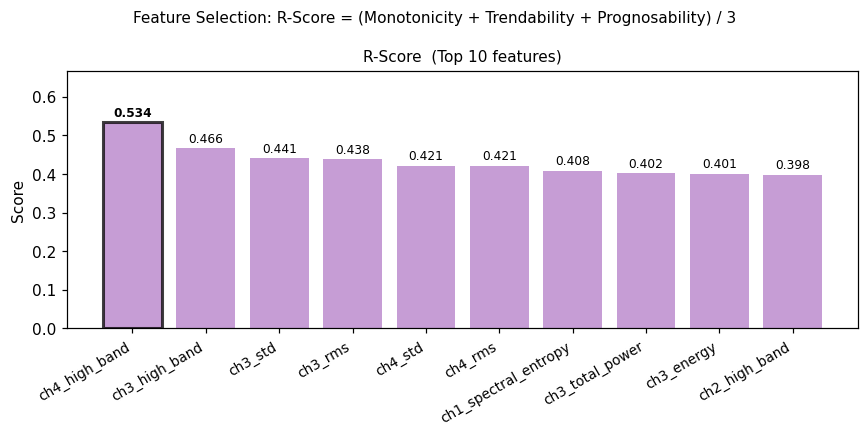

In [ ]:
# R-Score computation using feat_tr from Section 2 — no TDMS re-extraction
def _monotonicity(series):
    s = np.asarray(series, float)
    if len(s) <= 1: return 0.0
    d = np.diff(s)
    return float(abs(np.sum(d > 0) - np.sum(d < 0)) / len(d))

def _trendability(series):
    s = np.asarray(series, float)
    if len(s) <= 1: return 0.0
    rho, _ = spearmanr(np.arange(len(s)), s)
    return float(abs(rho) if not np.isnan(rho) else 0.0)

def _prognosability(series_list, k=5):
    eol_vals, init_vals = [], []
    for x in series_list:
        x = np.asarray(x, dtype=float); x = x[~np.isnan(x)]
        if len(x) < 3: continue
        ki = kf = min(k, len(x) // 2)
        init_vals.append(float(np.mean(x[:ki])))
        eol_vals.append(float(np.mean(x[-kf:])))
    if len(eol_vals) < 2: return 0.0
    eol, init = np.array(eol_vals), np.array(init_vals)
    sigma = np.std(eol)
    delta = np.mean(np.abs(eol - init))
    if delta < 1e-12: return 0.0
    return float(np.exp(-sigma / delta))

_FEAT_COLS_RS = [c for c in feat_tr[1].columns if c != "file_idx"]
rs_rows = {}
for col in _FEAT_COLS_RS:
    series = [feat_tr[b][col].values for b in BEARINGS]
    mon  = float(np.mean([_monotonicity(s) for s in series]))
    trnd = float(np.mean([_trendability(s) for s in series]))
    prog = _prognosability(series)
    rs_rows[col] = {"Monotonicity": round(mon, 4),
                    "Trendability": round(trnd, 4),
                    "Prognosability": round(prog, 4),
                    "R-Score": round((mon + trnd + prog) / 3, 4)}

rs_df = pd.DataFrame(rs_rows).T.sort_values("R-Score", ascending=False)
print(rs_df.to_string())
print(f"\n→ Selected: {rs_df.index[0]}  (R-Score = {rs_df['R-Score'].iloc[0]:.4f})")

top10 = rs_df.head(10)
fig, ax = plt.subplots(figsize=(8, 4))
vals = top10["R-Score"]; bi = 0  # index 0 is already top
bars = ax.bar(range(len(vals)), vals.values, color="#B47CC7", alpha=0.75, edgecolor="none")
bars[bi].set_edgecolor("black"); bars[bi].set_linewidth(2.0)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(vals.index, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, max(vals.values) * 1.25)
ax.set_title("R-Score  (Top 10 features)", fontsize=10)
ax.set_ylabel("Score")
for i, v in enumerate(vals.values):
    ax.text(i, v + max(vals.values) * 0.03, f"{v:.3f}", ha="center", fontsize=8,
            fontweight="bold" if i == bi else "normal")
fig.suptitle("Feature Selection: R-Score = (Monotonicity + Trendability + Prognosability) / 3",
             fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_rscore.png", bbox_inches="tight")
plt.show()

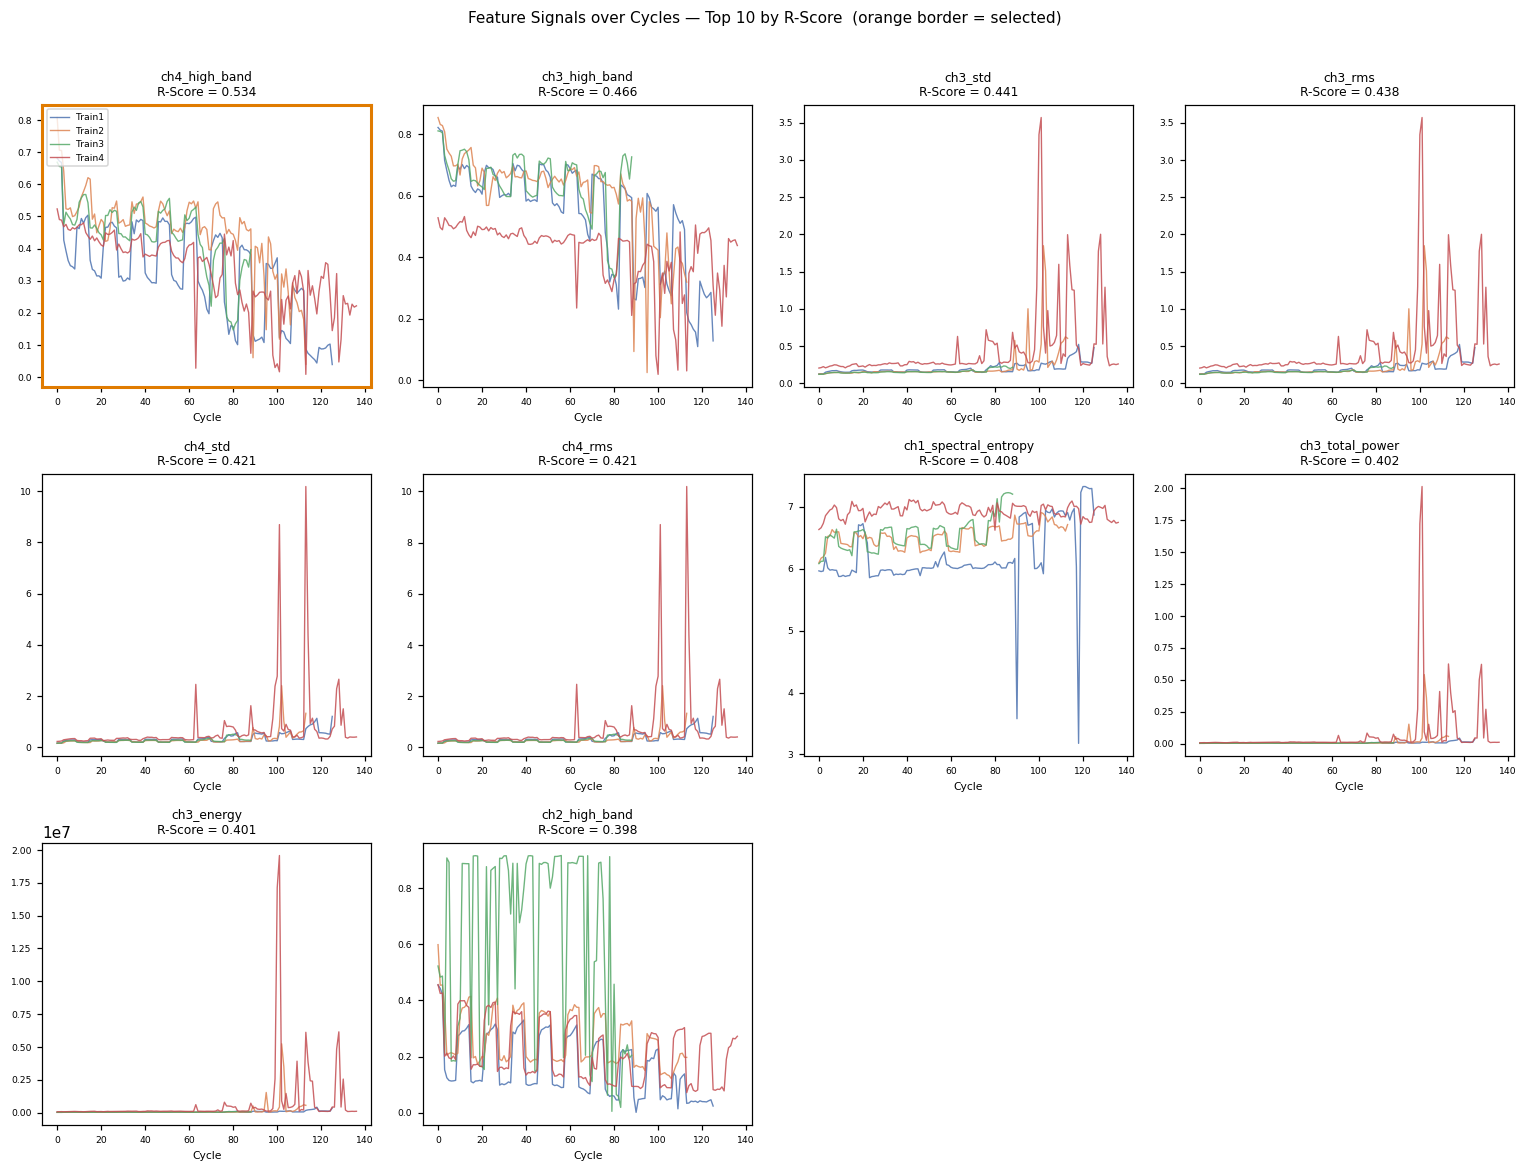

In [ ]:
# Plot raw feature signals over cycles for each feature (sorted by R-Score)
_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
_plot_feats = list(rs_df.index[:10])
_n_feat = len(_plot_feats)
_ncols = 4; _nrows = (_n_feat + _ncols - 1) // _ncols
fig, axes = plt.subplots(_nrows, _ncols, figsize=(14, 3.5 * _nrows))
axes = np.array(axes).reshape(_nrows, _ncols)

for idx, col in enumerate(_plot_feats):
    ax = axes[idx // _ncols][idx % _ncols]
    for i, b in enumerate(BEARINGS):
        ax.plot(feat_tr[b][col].values, color=_COLORS[i], alpha=0.85, linewidth=0.9, label=f"Train{b}")
    rscore = rs_df.loc[col, "R-Score"]
    ax.set_title(f"{col}\nR-Score = {rscore:.3f}", fontsize=8)
    ax.set_xlabel("Cycle", fontsize=7)
    ax.tick_params(labelsize=6)
    if idx == 0:
        ax.legend(fontsize=6, loc="upper left")
    # Highlight selected feature
    if col == rs_df.index[0]:
        for spine in ax.spines.values():
            spine.set_edgecolor("#e07b00"); spine.set_linewidth(2.0)

for idx in range(_n_feat, _nrows * _ncols):
    axes[idx // _ncols][idx % _ncols].set_visible(False)

fig.suptitle("Feature Signals over Cycles — Top 10 by R-Score  (orange border = selected)",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_hi_comparison.png", bbox_inches="tight")
plt.show()

## 4. 운전 레짐 분류 (저속 / 고속)

회전 속도가 1시간 간격으로 700~950 RPM 사이에서 변화. F2S2는 레짐(저속=0/고속=1) 정보를 사용
- **학습**: `Operation.csv`의 600초 윈도 평균 RPM이 850 초과면 고속(1)
- **검증**: Operation 데이터가 제공되지 않으므로, 열화 신호(`ch4_high_band`)에
  KMeans(2클러스터)를 적용해 레짐을 추정 (낮은 중심=저속=0)

In [ ]:
def regime_profile_train(bearing, n_cycle):
    # Operation.csv 평균 RPM 기반 cycle별 레짐 라벨.
    op = pd.read_csv(TRAIN_OP(bearing), encoding="latin-1")
    t   = op.iloc[:, 0].values.astype(np.float32)
    rpm = op.iloc[:, 2].values.astype(np.float32)
    lab = np.zeros(n_cycle, dtype=int)
    for k in range(n_cycle):
        m = (t >= k * INTERVAL) & (t < (k + 1) * INTERVAL)
        if m.sum() > 0:
            lab[k] = int(rpm[m].mean() > RPM_SPLIT)
        elif k > 0:
            lab[k] = lab[k - 1]
    return lab


def classify_regime_kmeans(y_arr):
    # Operation 없는 검증 데이터용: 신호값 KMeans 2클러스터 (낮은 중심=0)
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = km.fit_predict(y_arr.reshape(-1, 1))
    if km.cluster_centers_.flatten()[0] > km.cluster_centers_.flatten()[1]:
        labels = 1 - labels
    return labels.astype(int)


prof_tr = {b: regime_profile_train(b, len(y_tr[b])) for b in BEARINGS}
prof_te = {t: classify_regime_kmeans(y_te[t]) for t in TEST_IDS}
for b in BEARINGS:
    print(f"  Train{b}: low={np.sum(prof_tr[b]==0):3d}  high={np.sum(prof_tr[b]==1):3d}")

  Train1: low= 64  high= 62
  Train2: low= 58  high= 56
  Train3: low= 48  high= 41
  Train4: low= 69  high= 68


## 5. F2S2 상태공간 모델 

참고 논문
- N. Li, N. Gebraeel, Y. Lei, L. Bian, and X. Si, "Remaining useful life prediction of machinery under time-varying operating conditions based on a two-factor state-space model," Reliability Engineering & System Safety, vol. 186, pp. 88-100, 2019.

1. **상태전이 MLE** — 고장시각으로부터 레짐별 열화율 `R=(r_low=1, r_high)`, 드리프트 `η`, 분산 `σ²_B` 추정
2. **신호 baseline 변환** — 고속 레짐 신호를 저속(baseline) 조건으로 사상 (레짐 점프 제거)
3. **측정함수** — LOESS 평활로 `a_B, b_B, c, σ²` 추정
4. **파티클 필터** — 매 cycle 시스템 상태 `x_k` 추정 (= HI, 고장 임계 D=1)

In [ ]:
def _phi(profiles):
    return np.array([[np.sum(p == 0), np.sum(p == 1)] for p in profiles], np.float32)

def fit_state_transition(profiles):
    # 상태전이 MLE -> r_high, eta, sigma2_B (baseline r_low=1 고정).
    phi = _phi(profiles); N = len(phi)
    def nll(rh):
        R = np.array([1.0, rh], np.float32); tau = phi @ R
        if np.any(tau <= 0): return 1e18
        eta = N / np.sum(tau)
        s2 = max(np.mean((tau * eta - D_FAIL) ** 2 / tau), 1e-12)
        last_r = np.array([R[p[-1]] for p in profiles], np.float32)
        ll = (-N / 2 * np.log(2 * np.pi * s2) + np.sum(np.log(last_r))
              - np.sum(1.5 * np.log(tau))
              - np.sum((tau * eta - D_FAIL) ** 2 / (2 * s2 * tau)))
        return -ll
    res = minimize_scalar(nll, bounds=(0.2, 8.0), method="bounded")
    R = np.array([1.0, float(res.x)], np.float32); tau = phi @ R
    eta = float(N / np.sum(tau))
    s2 = float(max(np.mean((tau * eta - D_FAIL) ** 2 / tau), 1e-12))
    return {"r": R, "eta": eta, "sigma2_B": s2}

def tau_path(profile, R):
    inc = np.array([R[profile[max(j - 1, 0)]] for j in range(len(profile))], np.float32)
    return np.cumsum(inc)

def fit_signal_transform(series_list, profiles):
    # 고속 레짐 신호 -> baseline(저속) 조건 선형 사상 (a', b').
    Yh, Yb = [], []
    for y, p in zip(series_list, profiles):
        idx = np.arange(len(y)); low = idx[p == 0]; high = idx[p == 1]
        if len(low) < 2 or len(high) == 0: continue
        Yh.append(y[high]); Yb.append(np.interp(high, low, y[low]).astype(np.float32))
    if not Yh: return {0: (1.0, 0.0), 1: (1.0, 0.0)}
    yh = np.concatenate(Yh); yb = np.concatenate(Yb)
    def J(a):
        b = np.mean(yb - a * yh); return np.sum((yb - a * yh - b) ** 2)
    res = minimize_scalar(J, bounds=(1e-3, 1e3), method="bounded")
    a = float(res.x); b = float(np.mean(yb - a * yh))
    return {0: (1.0, 0.0), 1: (a, b)}

def transform_to_baseline(y, profile, trans):
    yb = y.astype(np.float32).copy()
    for c, (a, b) in trans.items():
        m = profile == c; yb[m] = a * y[m] + b
    return yb

def loess_smooth(y, frac=0.3):
    # 국소 가중 선형 회귀(LOESS) 평활.
    n = len(y); x = np.arange(n, dtype=np.float32); r = max(int(np.ceil(frac * n)), 3)
    out = np.empty(n, dtype=np.float32)
    for i in range(n):
        d = np.abs(x - x[i]); h = max(np.sort(d)[min(r, n - 1)], EPS)
        w = np.clip(1 - (d / h) ** 3, 0, 1) ** 3
        W = np.diag(w); X = np.vstack([np.ones(n, np.float32), x]).T
        try:
            beta = np.linalg.solve(X.T @ W @ X + 1e-9 * np.eye(2, dtype=np.float32), X.T @ W @ y)
            out[i] = beta[0] + beta[1] * x[i]
        except np.linalg.LinAlgError:
            out[i] = y[i]
    return out

def fit_measurement(yb_list, eta, R, profiles, loess_frac=0.3):
    # 측정함수 파라미터 a_B, b_B, sigma2, c 추정.
    sm = [loess_smooth(yb, loess_frac) for yb in yb_list]
    a_B = np.mean([s[-1] - s[0] for s in sm])
    a_B = a_B if abs(a_B) > EPS else (1.0 if a_B >= 0 else -1.0)
    b_B = np.mean([s[0] for s in sm]) / a_B
    sigma2 = np.mean([np.mean((yb - s) ** 2) for yb, s in zip(yb_list, sm)]) / (a_B ** 2 + EPS)
    taus = [tau_path(p, R) for p in profiles]
    def err_c(c):
        tot = 0.0
        for s, tau in zip(sm, taus):
            den = s[-1] - s[0]; den = den if abs(den) > EPS else EPS
            ratio = np.clip((s - s[0]) / den, 1e-6, 1.0)
            tot += np.sum((ratio ** (1.0 / c) - eta * tau) ** 2)
        return tot
    res = minimize_scalar(err_c, bounds=(0.5, 6.0), method="bounded")
    return {"a_B": float(a_B), "b_B": float(b_B),
            "sigma2": float(max(sigma2, 1e-9)), "c": float(res.x)}

def fit_params(train_bids, y, prof, lf=LOESS_FRAC):
    # 주어진 학습 베어링들로 F2S2 전체 파라미터 적합.
    profiles = [prof[b] for b in train_bids]; series = [y[b] for b in train_bids]
    st = fit_state_transition(profiles)
    trans = fit_signal_transform(series, profiles)
    yb = [transform_to_baseline(y[b], prof[b], trans) for b in train_bids]
    meas = fit_measurement(yb, st["eta"], st["r"], profiles, lf)
    return {**st, **{k: meas[k] for k in ("a_B", "b_B", "c", "sigma2")}, "trans": trans}

def _sysresample(w, local):
    n = len(w); pos = (local.random() + np.arange(n)) / n
    csum = np.cumsum(w); csum[-1] = 1.0
    return np.searchsorted(csum, pos)

def particle_filter(y, profile, params, n_particles=N_PARTICLES, seed=0):
    # 6 파티클 필터 -> cycle별 시스템 상태 x_k (HI).
    R, eta, s2B = params["r"], params["eta"], params["sigma2_B"]
    a_B, b_B, c, s2 = params["a_B"], params["b_B"], params["c"], params["sigma2"]
    trans = params["trans"]; local = np.random.default_rng(seed)
    K = len(y)
    x = np.zeros(n_particles, dtype=np.float32)
    w = np.full(n_particles, 1.0 / n_particles, dtype=np.float32)
    xbar = np.zeros(K, dtype=np.float32)
    for k in range(K):
        if k > 0:
            r_prev = R[profile[k - 1]]
            x = x + r_prev * eta + local.normal(0, np.sqrt(max(r_prev * s2B, 1e-12)), n_particles).astype(np.float32)
            x = np.clip(x, 0.0, None)
        a, b = trans[profile[k]]; yB = a * y[k] + b
        mean_meas = a_B * (b_B + np.clip(x, 0, None) ** c)
        var = a_B ** 2 * s2 + 1e-12
        logw = -(yB - mean_meas) ** 2 / (2 * var); logw -= logw.max()
        w = w * np.exp(logw); sw = w.sum()
        w = np.full(n_particles, 1.0/n_particles, dtype=np.float32) if (sw <= 0 or not np.isfinite(sw)) else w / sw
        x = x[_sysresample(w, local)]
        w = np.full(n_particles, 1.0 / n_particles, dtype=np.float32)
        xbar[k] = np.median(x)
    return xbar.astype(np.float32)

print("F2S2 core ready")

F2S2 core ready


## 6. Health Indicator 생성

- **학습 HI**: Leave-One-Out — 각 베어링의 HI를 *나머지 3개*로 적합한 파라미터로 추정 (자기 정보 누설 방지)
- **검증 HI**: 학습 4개 전체로 적합한 파라미터로 각 Test 베어링 HI 추정

In [ ]:
# 학습 HI (LOO) + LOO 파라미터 저장 (시각화용)
loo_params_tr = {}
state_tr = {}
for tb in BEARINGS:
    p = fit_params([b for b in BEARINGS if b != tb], y_tr, prof_tr)
    loo_params_tr[tb] = p
    state_tr[tb] = particle_filter(y_tr[tb], prof_tr[tb], p, seed=tb)

# 검증 HI (전체 학습 적합)
params_all = fit_params(BEARINGS, y_tr, prof_tr)
state_te = {t: particle_filter(y_te[t], prof_te[t], params_all, seed=t + 100) for t in TEST_IDS}

# state_x 저장
for b in BEARINGS:
    pd.DataFrame({"cycle": np.arange(len(state_tr[b])),
                  "state_x": state_tr[b], "regime": prof_tr[b]}
                 ).to_csv(OUT_DIR / f"state_Bearing{b}.csv", index=False)
for t in TEST_IDS:
    pd.DataFrame({"cycle": np.arange(len(state_te[t])),
                  "state_x": state_te[t], "regime": prof_te[t]}
                 ).to_csv(OUT_DIR / f"state_Test{t}.csv", index=False)
print("HI 생성/저장 완료 ->", OUT_DIR)

HI 생성/저장 완료 -> output


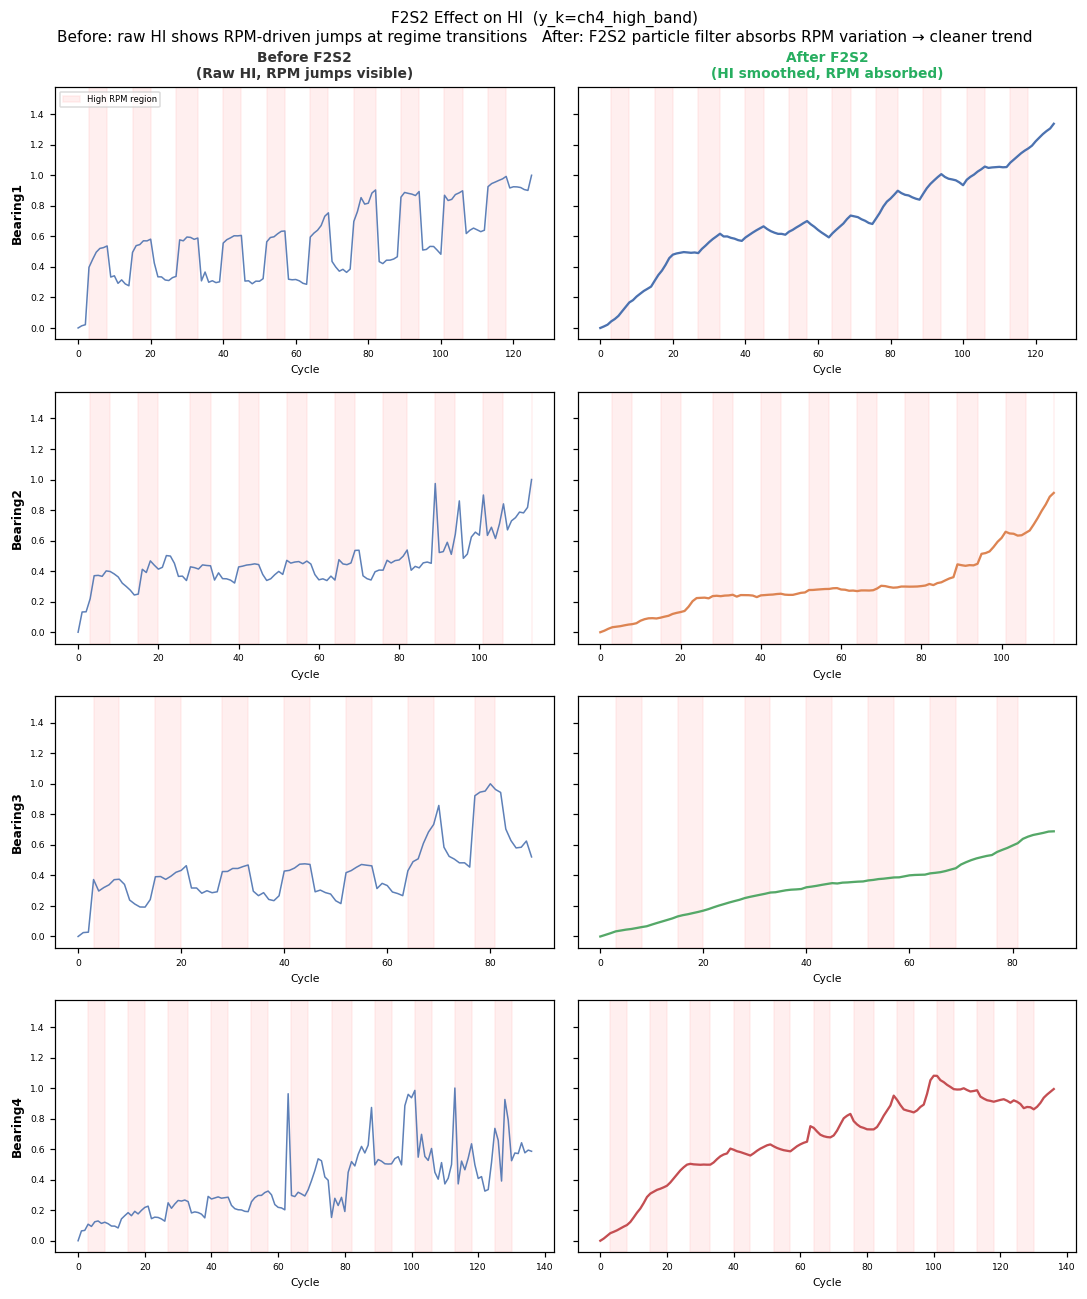

In [ ]:
def _raw_hi(y):
    mn, mx = y.min(), y.max()
    return (1.0 - (y - mn) / (mx - mn + 1e-9)).astype(np.float32)

_tr_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# 4×2: rows = bearings (1-4), cols = (Before F2S2, After F2S2)
fig, axes = plt.subplots(4, 2, figsize=(10, 12), sharey="row")

for i, b in enumerate(BEARINGS):
    yraw    = y_tr[b]; prof = prof_tr[b]; cyc = np.arange(len(yraw))
    hi_raw  = _raw_hi(yraw)
    hi_f2s2 = state_tr[b]
    m_hi = (prof == 1)

    # ── Col 0: Before F2S2 (raw HI, single line + regime shading) ────────────
    ax = axes[i, 0]
    ax.fill_between(cyc, 0, 1.5, where=m_hi, color="#FFCCCC", alpha=0.3,
                    transform=ax.get_xaxis_transform(), label="High RPM region")
    ax.plot(cyc, hi_raw, color="#4C72B0", linewidth=1.0, alpha=0.9)
    # 1.0 (D_FAIL) 수평선 삭제
    # ax.axhline(D_FAIL, color="#E74C3C", linestyle="--", linewidth=0.8, alpha=0.7)
    
    ax.set_ylabel(f"Bearing{b}", fontsize=8, fontweight="bold")
    ax.set_xlabel("Cycle", fontsize=7); ax.tick_params(labelsize=6)
    if i == 0:
        ax.set_title("Before F2S2\n(Raw HI, RPM jumps visible)", fontsize=9,
                     fontweight="bold", color="#333333")
        ax.legend(fontsize=5.5, loc="upper left", framealpha=0.7)

    # ── Col 1: After F2S2 (particle filter HI) ───────────────────────────────
    ax2 = axes[i, 1]
    ax2.fill_between(cyc, 0, 1.5, where=m_hi, color="#FFCCCC", alpha=0.3,
                     transform=ax2.get_xaxis_transform())
    ax2.plot(cyc, hi_f2s2, color=_tr_colors[i], linewidth=1.5)
    # 1.0 (D_FAIL) 수평선 삭제
    # ax2.axhline(D_FAIL, color="#E74C3C", linestyle="--", linewidth=0.8, alpha=0.7)
    
    ax2.set_xlabel("Cycle", fontsize=7); ax2.tick_params(labelsize=6)
    if i == 0:
        ax2.set_title("After F2S2\n(HI smoothed, RPM absorbed)", fontsize=9,
                      fontweight="bold", color="#27AE60")

fig.suptitle(
    f"F2S2 Effect on HI  (y_k={YCOL})\n"
    "Before: raw HI shows RPM-driven jumps at regime transitions   "
    "After: F2S2 particle filter absorbs RPM variation → cleaner trend",
    fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "f2s2_hi_construction.png", bbox_inches="tight")
plt.show()

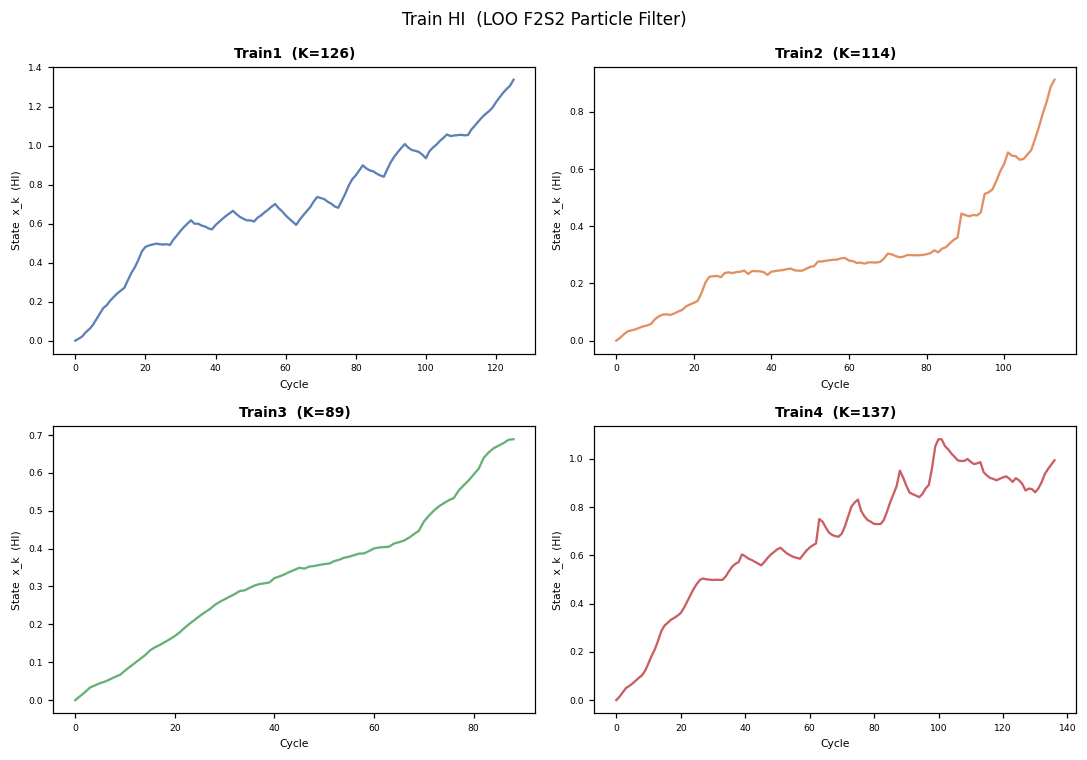

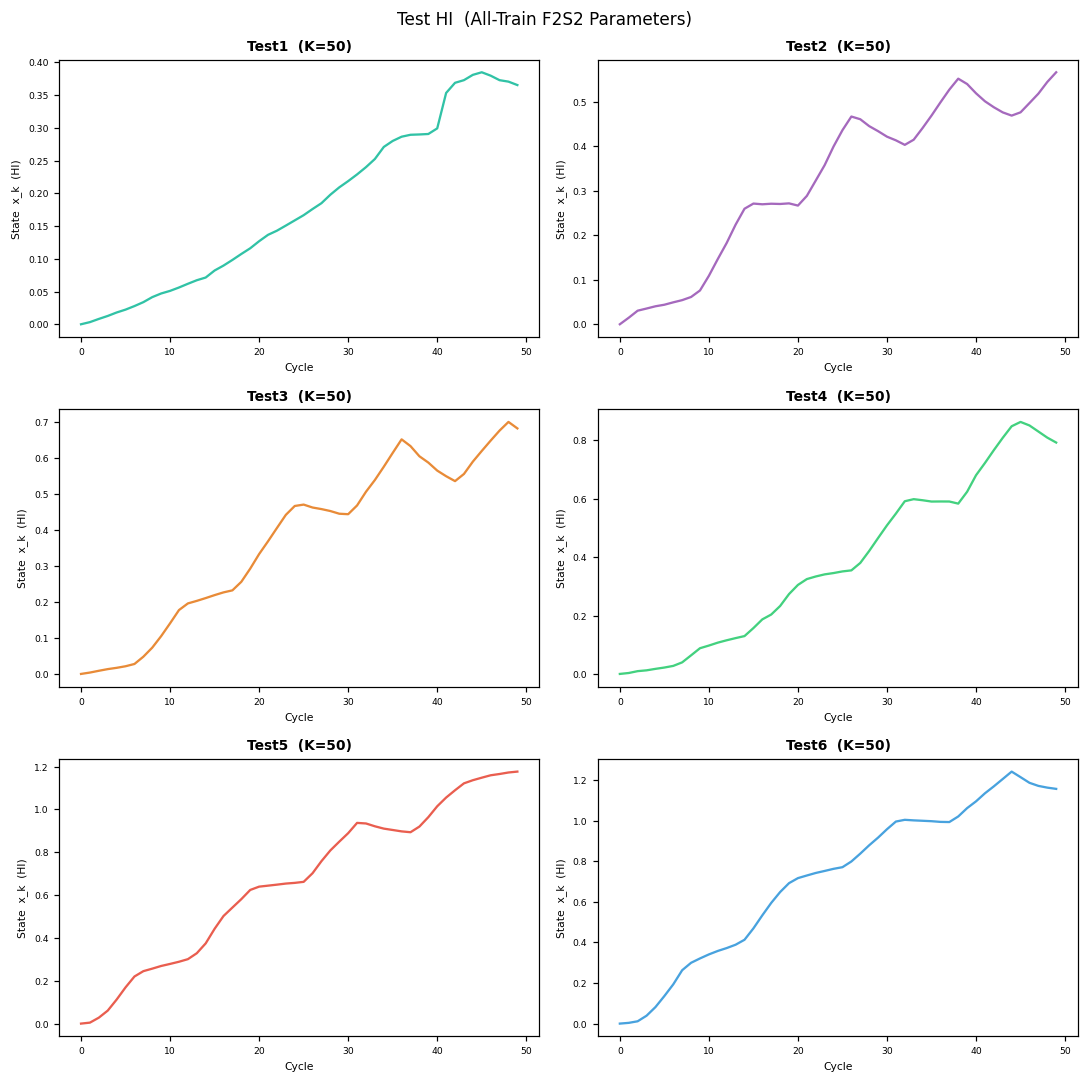

In [ ]:
_tr_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
_te_colors = ["#1ABC9C", "#9B59B6", "#E67E22", "#2ECC71", "#E74C3C", "#3498DB"]

# ── Train HI (LOO) — 2×2 ─────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(10, 7))
for i, b in enumerate(BEARINGS):
    ax = axes1[i // 2, i % 2]
    hi = state_tr[b]; cyc = np.arange(len(hi))
    ax.plot(cyc, hi, color=_tr_colors[i], linewidth=1.5, alpha=0.9)
    
    ax.set_title(f"Train{b}  (K={len(hi)})", fontsize=9, fontweight="bold")
    ax.set_xlabel("Cycle", fontsize=7); ax.set_ylabel("State  x_k  (HI)", fontsize=7)
    ax.tick_params(labelsize=6)

fig1.suptitle("Train HI  (LOO F2S2 Particle Filter)", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "train_hi_loo.png", bbox_inches="tight")
plt.show()

# ── Test HI (all-train params) — 3×2 ─────────────────────────────────────────
fig2, axes2 = plt.subplots(3, 2, figsize=(10, 10))
for i, t in enumerate(TEST_IDS):
    ax = axes2[i // 2, i % 2]
    hi = state_te[t]; cyc = np.arange(len(hi))
    ax.plot(cyc, hi, color=_te_colors[i], linewidth=1.5, alpha=0.9)
    
    # ax.axhline(D_FAIL, color="#E74C3C", linestyle="--", linewidth=0.9, alpha=0.85,
    #            label=f"D_fail={D_FAIL}")
               
    ax.set_title(f"Test{t}  (K={len(hi)})", fontsize=9, fontweight="bold")
    ax.set_xlabel("Cycle", fontsize=7); ax.set_ylabel("State  x_k  (HI)", fontsize=7)
    ax.tick_params(labelsize=6)
        
fig2.suptitle("Test HI  (All-Train F2S2 Parameters)", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "test_hi_allparams.png", bbox_inches="tight")
plt.show()

## 7. RUL 회귀 모델 비교 (LSTM / Transformer / TCN)

동일한 HI 시퀀스(길이 `WINDOW=10`)와 학습 조건으로 세 가지 시계열 회귀 모델을 비교

| 항목 | LSTM | Transformer | TCN |
|---|---|---|---|
| 구조 | LSTM(hidden=32) → FC(1) | Linear → TransformerEncoder(d=32, head=4, L=2) → FC(1) | DilatedConv(1→32→32, ks=3) → FC(1) |
| Window | 10 cycles | 10 cycles | 10 cycles |
| Epochs / LR | 300 / 3e-3 Adam MSE | 300 / 3e-3 | 300 / 3e-3 |
| 정규화 | RUL을 y_max로 0~1 정규화 | 동일 | 동일 |

In [ ]:
# ── Model definitions ─────────────────────────────────────────────────────────
class LSTMReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, HIDDEN, batch_first=True)
        self.fc = nn.Linear(HIDDEN, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(1)


class TransformerReg(nn.Module):
    def __init__(self, d_model=32, nhead=4, num_layers=2, dim_ff=64):
        super().__init__()
        self.proj = nn.Linear(1, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff,
                                               batch_first=True, dropout=0.0)
        self.enc = nn.TransformerEncoder(enc_layer, num_layers)
        self.fc  = nn.Linear(d_model, 1)
    def forward(self, x):
        return self.fc(self.enc(self.proj(x))[:, -1, :]).squeeze(1)


class _TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks, dil):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, ks, dilation=dil, padding=(ks - 1) * dil)
        self.relu = nn.ReLU()
        self.res  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        out = self.relu(self.conv(x)[..., :x.shape[-1]])
        return self.relu(out + self.res(x))

class TCNReg(nn.Module):
    def __init__(self, channels=(32, 32), ks=3):
        super().__init__()
        layers, in_ch = [], 1
        for i, out_ch in enumerate(channels):
            layers.append(_TCNBlock(in_ch, out_ch, ks, 2 ** i)); in_ch = out_ch
        self.tcn = nn.Sequential(*layers)
        self.fc  = nn.Linear(channels[-1], 1)
    def forward(self, x):
        return self.fc(self.tcn(x.transpose(1, 2))[..., -1]).squeeze(1)


# ── Generic train / predict (model-agnostic) ──────────────────────────────────
def _make_dataset(train_his):
    Xs, ys = [], []
    for b, hi in train_his.items():
        K = len(hi)
        for k in range(WINDOW, K):
            Xs.append(hi[k - WINDOW:k]); ys.append(float(K - k))
    X = np.array(Xs, np.float32); y = np.array(ys, np.float32)
    return X, y, float(y.max()) + 1e-9

def train_model(model_fn, train_his, epochs=EPOCHS, lr=LR):
    torch.manual_seed(SEED); np.random.seed(SEED)
    g = torch.Generator(); g.manual_seed(SEED)
    model = model_fn()
    X, y, y_max = _make_dataset(train_his)
    ds = TensorDataset(torch.tensor(X).unsqueeze(-1), torch.tensor(y / y_max))
    loader = DataLoader(ds, batch_size=32, shuffle=True, generator=g)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            loss = nn.MSELoss()(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model, y_max

def predict_seq(test_hi, model, y_max):
    model.eval(); K = len(test_hi); preds = np.zeros(K, np.float32)
    with torch.no_grad():
        for k in range(K):
            if k < WINDOW:
                preds[k] = float(K - k)
            else:
                x = torch.tensor(test_hi[k - WINDOW:k]).view(1, WINDOW, 1)
                preds[k] = max(1.0, float(model(x).item()) * y_max)
    return preds

def predict_last(test_hi, model, y_max):
    model.eval(); K = len(test_hi)
    with torch.no_grad():
        if K < WINDOW: return float(K)
        x = torch.tensor(test_hi[K - WINDOW:K]).view(1, WINDOW, 1)
        return max(1.0, float(model(x).item()) * y_max)

# backward-compatible aliases
train_lstm        = lambda his: train_model(LSTMReg, his)
predict_lstm_seq  = predict_seq
predict_lstm_last = predict_last

print("LSTM / Transformer / TCN defined")

LSTM / Transformer / TCN defined


### 7-1. LOO 검증: LSTM vs. Transformer vs. TCN

Score: `ER = 100·(True−Pred)/True`,  `ER≤0 → 0.5^(ER/20)`,  `ER>0 → 0.5^(ER/50)`

동일한 LOO 프로토콜로 세 모델을 평가. **Transformer**가 가장 높은 평균 score를 달성함을 확인

LSTM done
Transformer done
TCN done

Arch            Train1  Train2  Train3  Train4     Mean
-----------------------------------------------------
LSTM            0.6029  0.4498  0.3776  0.5967   0.5068
Transformer     0.6165  0.4893  0.3269  0.6771   0.5274
TCN             0.5835  0.4415  0.2382  0.5463   0.4524

→ Best model: Transformer  (LOO score_fpt = 0.5274)


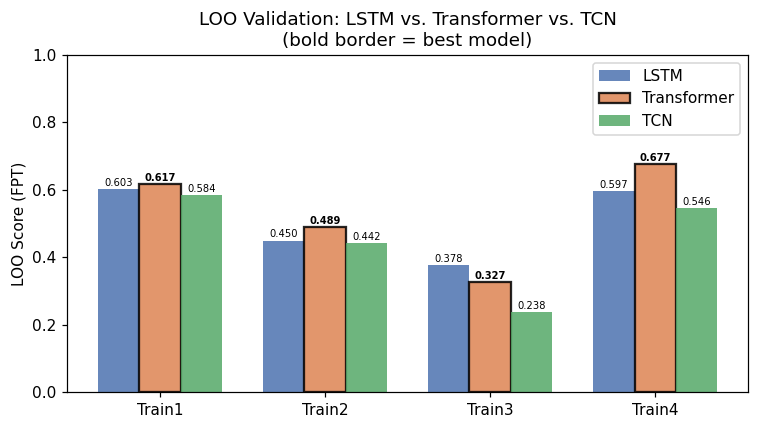

In [ ]:
def competition_score(true, pred):
    if true <= 0: return np.nan
    er = 100.0 * (true - pred) / true
    return float(np.exp(-np.log(0.5) * er / 20.0) if er <= 0 else np.exp(np.log(0.5) * er / 50.0))

def find_fpt(hi, frac0=0.1):
    n0 = max(5, int(len(hi) * frac0))
    mu, sd = hi[:n0].mean(), hi[:n0].std() + 1e-9
    above = np.where(hi > mu + 3 * sd)[0]
    return int(above[0]) if len(above) else n0

ARCH_MAP = {"LSTM": LSTMReg, "Transformer": TransformerReg, "TCN": TCNReg}
loo_all, loo_curves = {}, {}

for arch_name, model_fn in ARCH_MAP.items():
    rows = []
    for tb in BEARINGS:
        model, y_max = train_model(model_fn, {b: state_tr[b] for b in BEARINGS if b != tb})
        K   = len(state_tr[tb])
        preds = predict_seq(state_tr[tb], model, y_max)
        true  = np.maximum(K - np.arange(K), 1.0).astype(np.float32)
        fpt   = find_fpt(state_tr[tb])
        sc_fpt  = np.nanmean([competition_score(t, p) for t, p in zip(true[fpt:], preds[fpt:])])
        sc_full = np.nanmean([competition_score(t, p) for t, p in zip(true, preds)])
        rows.append({"bearing": tb, "fpt": fpt,
                     "score_fpt":  round(float(sc_fpt), 4),
                     "score_full": round(float(sc_full), 4)})
        loo_curves.setdefault(arch_name, {})[tb] = (true, preds, fpt)
    loo_all[arch_name] = pd.DataFrame(rows)
    print(f"{arch_name} done")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Arch':<14} {'Train1':>7} {'Train2':>7} {'Train3':>7} {'Train4':>7} {'Mean':>8}")
print("-" * 53)
means = {}
for arch, df in loo_all.items():
    sc = df["score_fpt"].values; m = sc.mean(); means[arch] = m
    print(f"{arch:<14} {sc[0]:>7.4f} {sc[1]:>7.4f} {sc[2]:>7.4f} {sc[3]:>7.4f} {m:>8.4f}")

best_arch = max(means, key=means.get)
print(f"\n→ Best model: {best_arch}  (LOO score_fpt = {means[best_arch]:.4f})")

loo_df = loo_all["Transformer"]
loo_df.to_csv(OUT_DIR / "transformer_loo_scores.csv", index=False)

# ── Bar chart comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(BEARINGS)); w = 0.25
_arch_colors = {"LSTM": "#4C72B0", "Transformer": "#DD8452", "TCN": "#55A868"}
for i, (arch, df) in enumerate(loo_all.items()):
    vals = df["score_fpt"].values
    bars = ax.bar(x + (i - 1) * w, vals, w, label=arch,
                  color=_arch_colors[arch], alpha=0.85)
    if arch == best_arch:
        for bar in bars:
            bar.set_edgecolor("black"); bar.set_linewidth(1.5)
    for j, v in enumerate(vals):
        ax.text(x[j] + (i - 1) * w, v + 0.01, f"{v:.3f}",
                ha="center", fontsize=6.5,
                fontweight="bold" if arch == best_arch else "normal")

ax.set_xticks(x)
ax.set_xticklabels([f"Train{b}" for b in BEARINGS])
ax.set_ylabel("LOO Score (FPT)")
ax.set_ylim(0, 1.0)
ax.legend()
ax.set_title("LOO Validation: LSTM vs. Transformer vs. TCN\n(bold border = best model)")
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison_loo.png", bbox_inches="tight")
plt.show()

### 7-2. 보수성 분석: LSTM을 최종 모델 선택

LOO 점수는 Transformer가 가장 높지만, 실제 설비에서는 RUL을 실제보다 길게 예측(과대 예측)하면 고장 경보를 놓치는 위험이 생김.
보수적 예측(실제보다 짧게 = 더 일찍 경보)이 안전 측 선택이므로 아래 지표로 세 모델을 비교함.

| 지표 | 정의 | 보수적 방향 |
|---|---|---|
| **Signed Bias** | mean(예측 RUL − 실제 RUL) | 음수(−) |
| **과대 예측 면적** | Σ max(예측 − 실제, 0) | 작을수록 |
| **과소 예측 면적** | Σ max(실제 − 예측, 0) | 클수록 |

<br>

> **핵심 판단 기준 — Signed Bias**  
> Signed Bias가 음수(−)이면 평균적으로 실제보다 짧게 예측 → 경보를 일찍 발생 → 안전.  
> 양수(+)이면 평균적으로 실제보다 길게 예측 → 고장 경보를 놓칠 위험.  

In [ ]:
# ── 7-2. 보수성 분석 (FPT → EOL 구간) ───────────────────────────────────────
bias_records = []
for arch_name in ARCH_MAP:
    for tb in BEARINGS:
        true, preds, fpt = loo_curves[arch_name][tb]
        t = true[fpt:].astype(np.float32)
        p = preds[fpt:].astype(np.float32)
        err = p - t  # 양수=과대예측(위험), 음수=과소예측(보수적)
        bias_records.append({
            "arch": arch_name, "bearing": tb,
            "signed_bias": float(err.mean()),
            "over_area":   float(np.maximum(err, 0).sum()),
            "under_area":  float(np.maximum(-err, 0).sum()),
        })
bias_df = pd.DataFrame(bias_records)

print('=== 보수성 분석 요약 (FPT 이후 구간, 베어링 4개 평균) ===')
print(f"{'모델':<14} {'Signed Bias':>12} {'과대예측면적':>13} {'과소예측면적':>13}")
print('-' * 54)
arch_summary = {}
for arch_name in ARCH_MAP:
    sub = bias_df[bias_df['arch'] == arch_name]
    b  = sub['signed_bias'].mean()
    oa = sub['over_area'].mean()
    ua = sub['under_area'].mean()
    arch_summary[arch_name] = dict(bias=b, over_area=oa, under_area=ua)
    print(f"{arch_name:<14} {b:>+12.2f} {oa:>13.1f} {ua:>13.1f}")

print()
print('【핵심 판단: Signed Bias의 부호】')
print('  음수(−) = 평균적으로 실제보다 짧게 예측 → 경보 일찍 발생 → 안전(보수적)')
print('  양수(+) = 평균적으로 실제보다 길게 예측 → 고장 경보 누락 위험')
print()
for arch, v in arch_summary.items():
    direction = '보수적 (안전 측) ← 최종 선택' if v['bias'] < 0 else '과대 예측 방향 (위험)'
    mark = '✓' if v['bias'] < 0 else '✗'
    print(f'  {arch:<14}: Signed Bias = {v["bias"]:+.2f}  {mark} {direction}')

# ── 시각화 (그래프 텍스트는 영문 유지) ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for row_i, arch_name in enumerate(['LSTM', 'Transformer']):
    for col_i, tb in enumerate(BEARINGS):
        ax = axes[row_i][col_i]
        true, preds, fpt = loo_curves[arch_name][tb]
        x = np.arange(len(true))
        ax.plot(x, true,  color='black', linewidth=1.3, label='True RUL', zorder=3)
        ax.plot(x, preds,
                color='#4C72B0' if arch_name == 'LSTM' else '#DD8452',
                linewidth=1.0, alpha=0.9, label=arch_name, zorder=2)
        ax.fill_between(x, true, preds, where=(preds > true),
                        alpha=0.35, color='red',   label='Over-predict (risky)')
        ax.fill_between(x, true, preds, where=(preds <= true),
                        alpha=0.25, color='green', label='Under-predict (safe)')

        sub = bias_df[(bias_df['arch'] == arch_name) & (bias_df['bearing'] == tb)]
        b_val = float(sub['signed_bias'].values[0])
        ax.set_title(f'{arch_name} - Train{tb}\nbias={b_val:+.1f}', fontsize=8)
        ax.set_xlabel('Cycle', fontsize=7)
        if col_i == 0:
            ax.set_ylabel('RUL (cycles)', fontsize=7)
        ax.tick_params(labelsize=6)
        if row_i == 0 and col_i == 3:
            ax.legend(fontsize=5.5, loc='upper right')
fig.suptitle(
    'Conservative Bias Analysis  (FPT to EOL)\n'
    'Red = over-prediction (overestimates remaining life, misses failure warning)\n'
    'Green = under-prediction (conservative, triggers alarms earlier)',
    fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'conservative_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

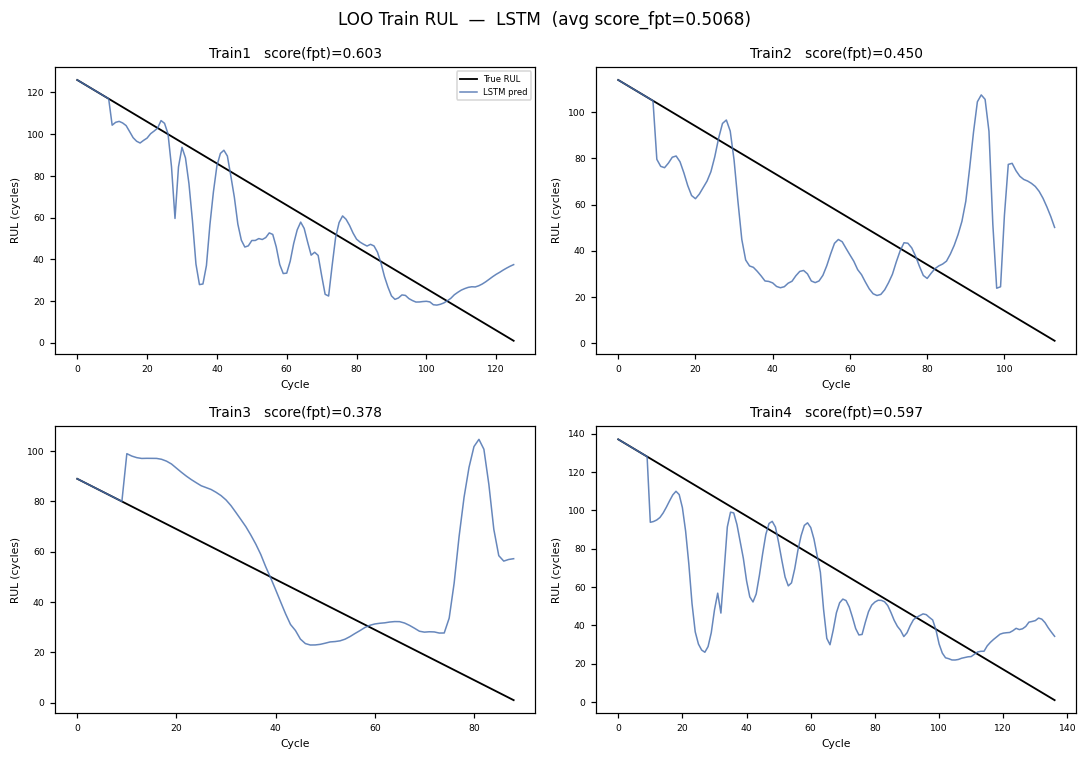

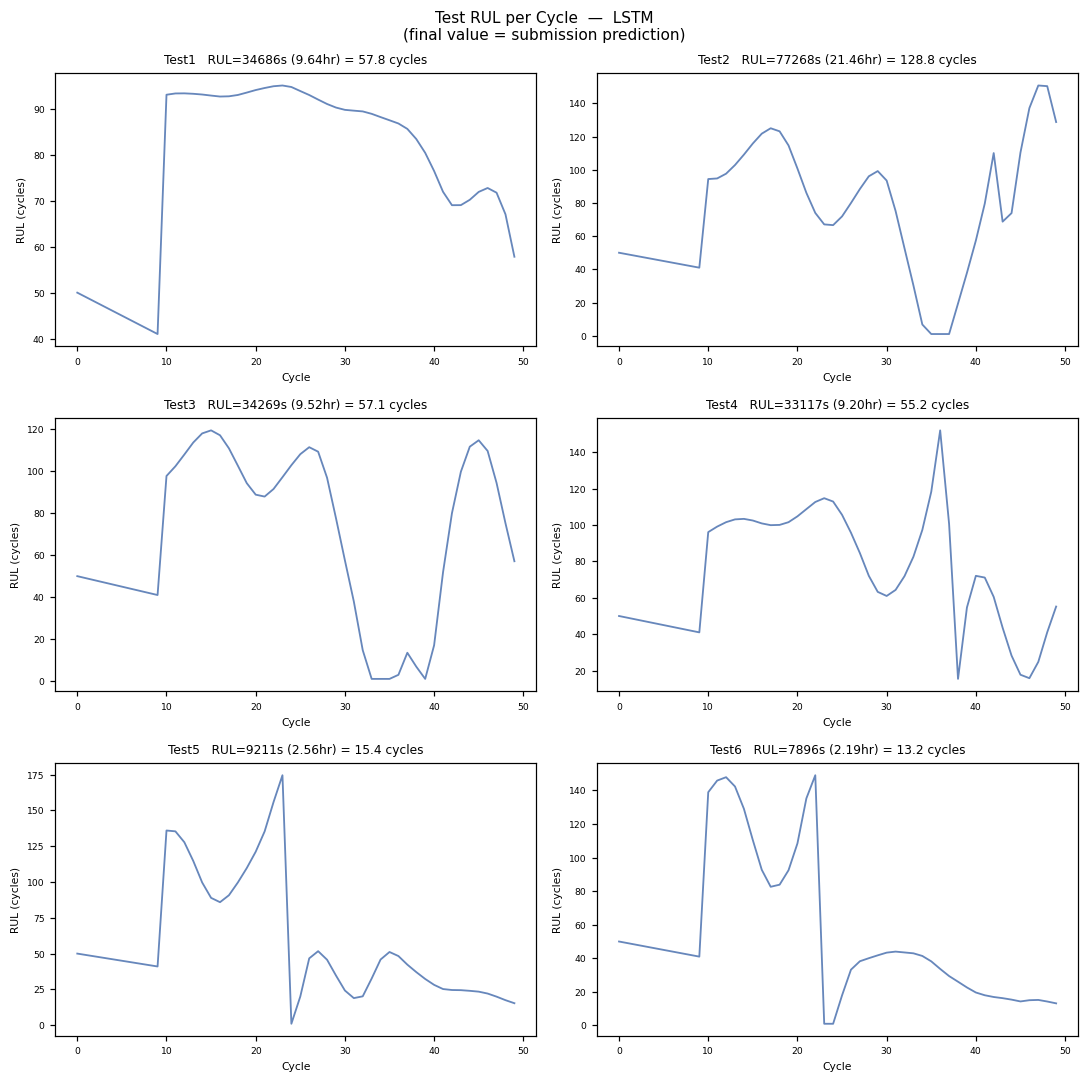

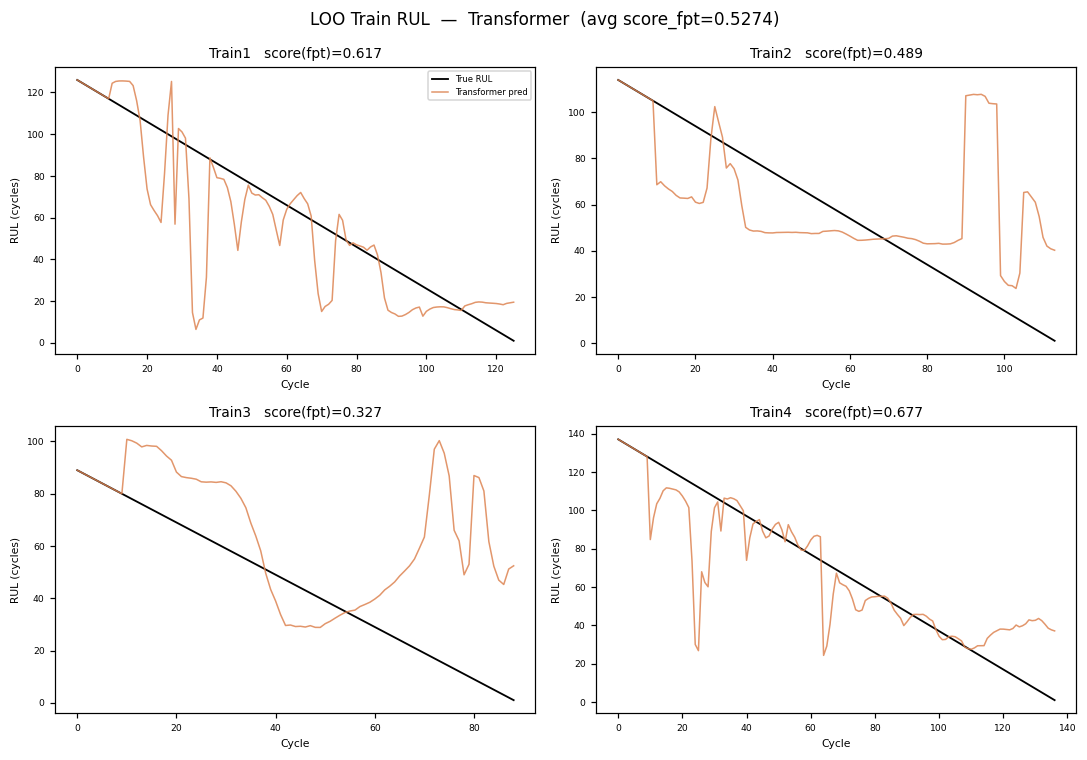

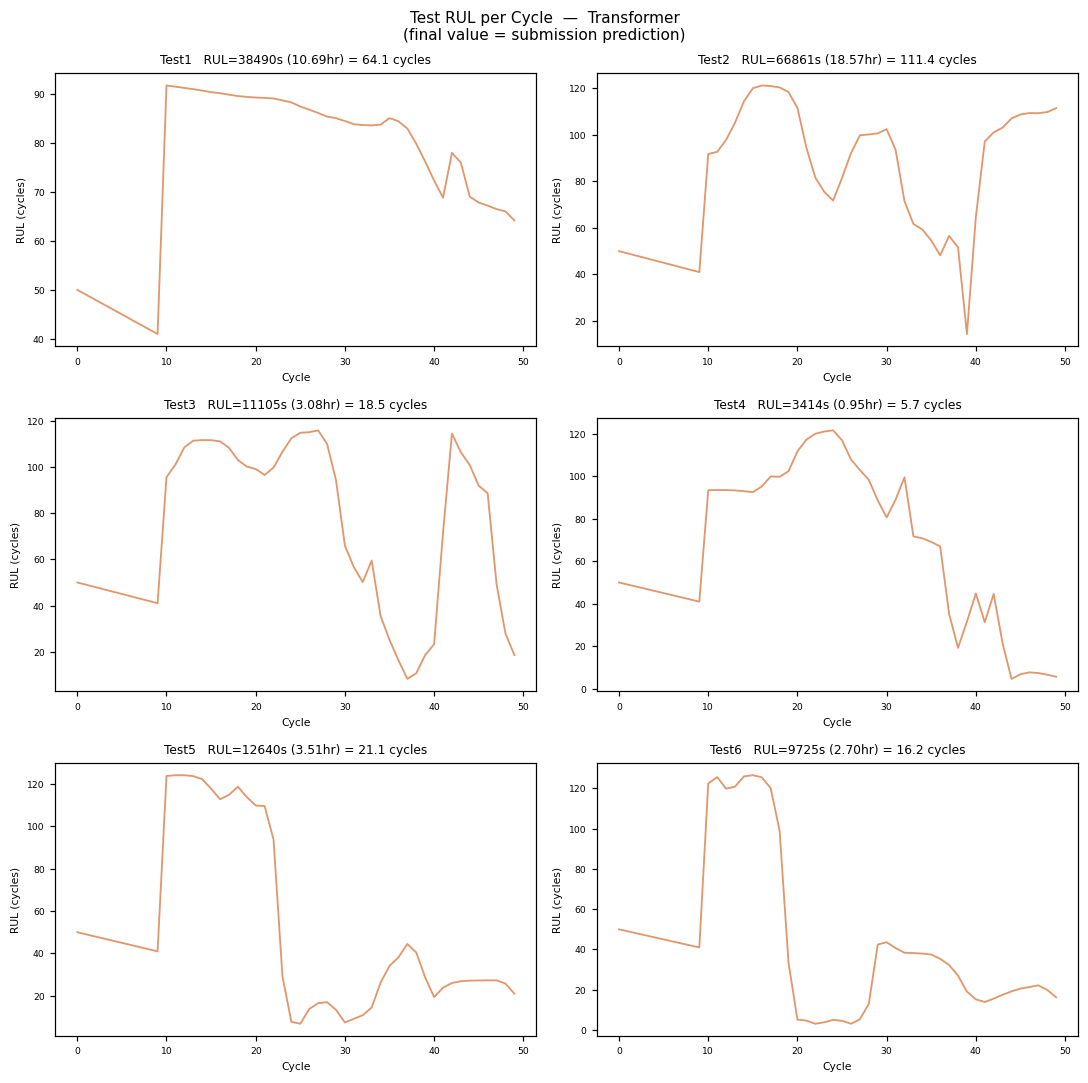

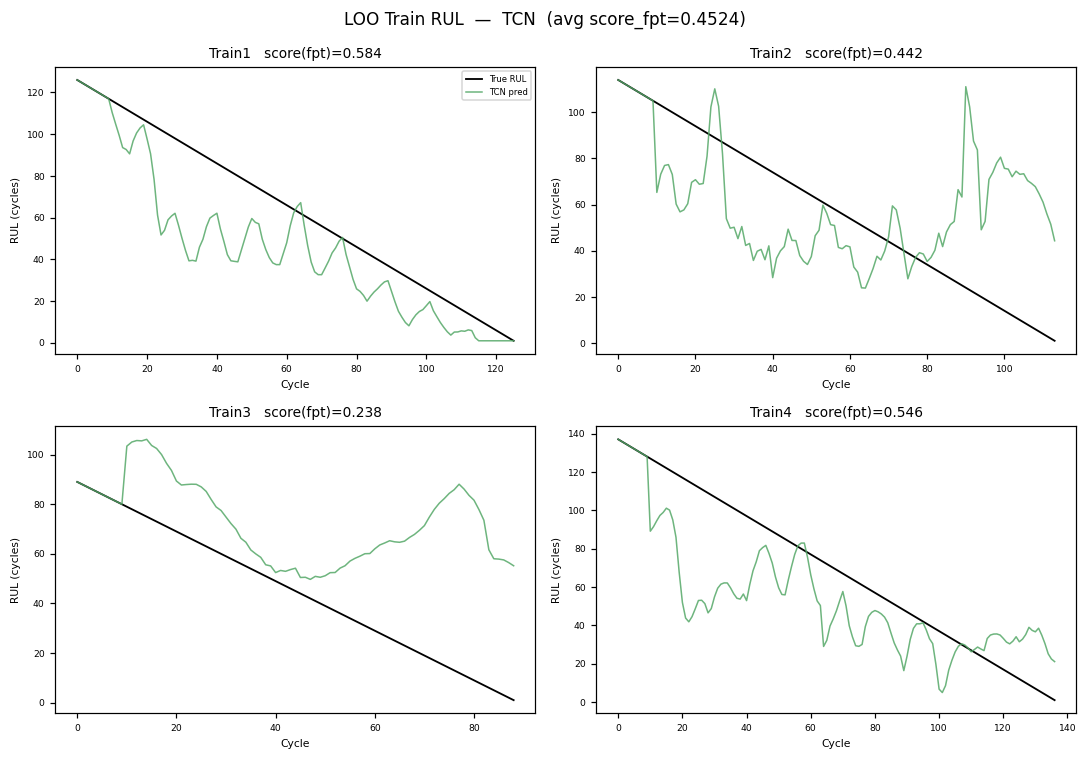

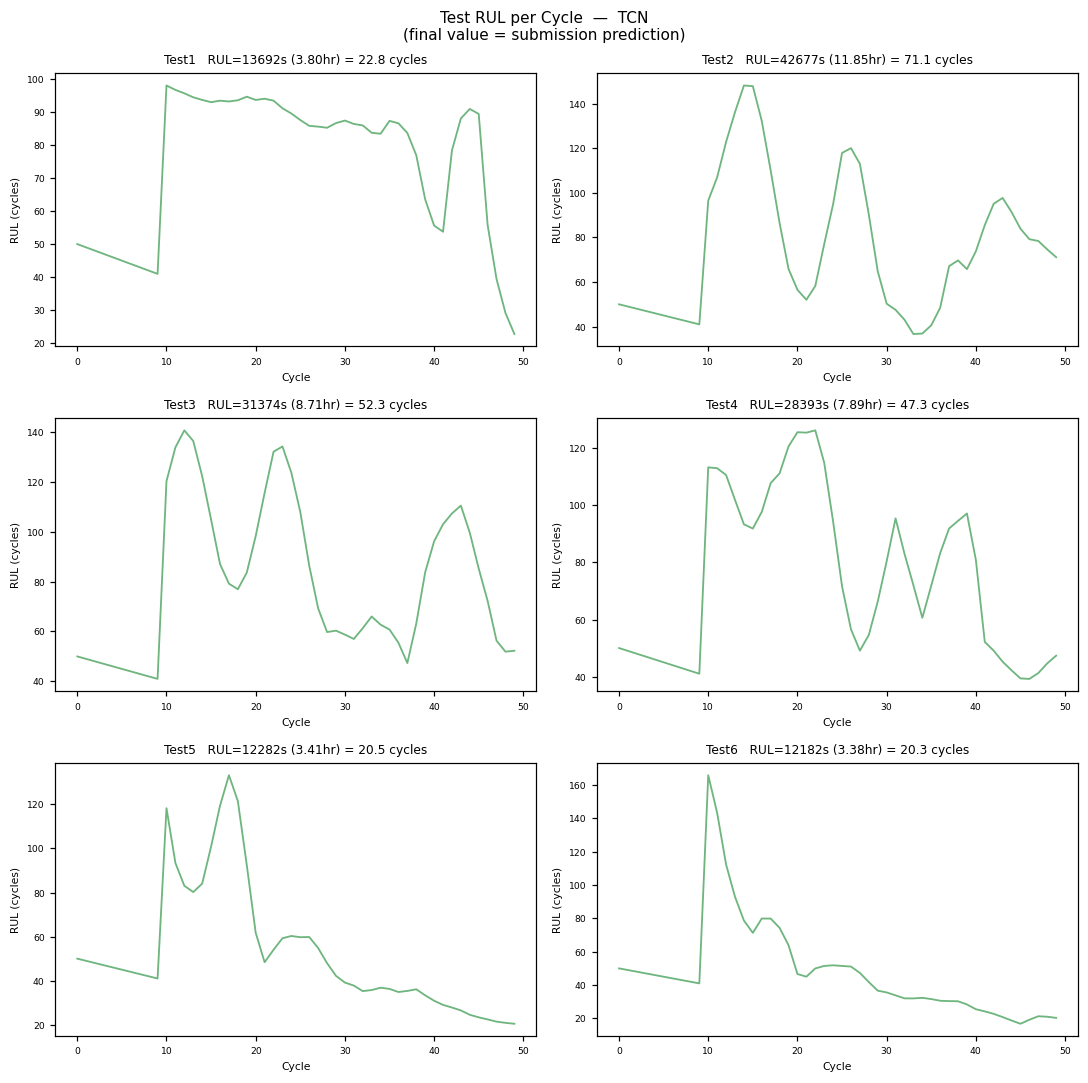

In [ ]:
# Train all-arch final models for test RUL curves
arch_final_models = {}
for _an, _mfn in ARCH_MAP.items():
    _m, _ym = train_model(_mfn, state_tr)
    arch_final_models[_an] = (_m, _ym)

test_seqs_all = {
    an: {t: predict_seq(state_te[t], m, ym) for t in TEST_IDS}
    for an, (m, ym) in arch_final_models.items()
}

_arch_colors_v = {"LSTM": "#4C72B0", "Transformer": "#DD8452", "TCN": "#55A868"}
avg_scores = {an: loo_all[an]["score_fpt"].mean() for an in ARCH_MAP}

for an in ["LSTM", "Transformer", "TCN"]:
    color = _arch_colors_v[an]

    # ── LOO Train RUL — 2×2 ──────────────────────────────────────────────────
    fig1, axes1 = plt.subplots(2, 2, figsize=(10, 7))
    for i, b in enumerate(BEARINGS):
        ax = axes1[i // 2, i % 2]
        true_rul, preds, fpt = loo_curves[an][b]
        sc = loo_all[an].loc[loo_all[an]["bearing"] == b, "score_fpt"].values[0]
        ax.plot(true_rul, color="black",  linewidth=1.2, label="True RUL")
        ax.plot(preds,    color=color,    linewidth=1.0, alpha=0.85, label=f"{an} pred")
        
        ax.set_title(f"Train{b}   score(fpt)={sc:.3f}", fontsize=9)
        ax.set_xlabel("Cycle", fontsize=7); ax.set_ylabel("RUL (cycles)", fontsize=7)
        ax.tick_params(labelsize=6)
        if i == 0:
            ax.legend(fontsize=5.5)
    fig1.suptitle(f"LOO Train RUL  —  {an}  (avg score_fpt={avg_scores[an]:.4f})", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"rul_loo_{an.lower()}.png", bbox_inches="tight")
    plt.show()

    # ── Test RUL per-cycle — 3×2 ─────────────────────────────────────────────
    fig2, axes2 = plt.subplots(3, 2, figsize=(10, 10))
    for i, t in enumerate(TEST_IDS):
        ax = axes2[i // 2, i % 2]
        preds_te = test_seqs_all[an][t]
        ax.plot(preds_te, color=color, linewidth=1.2, alpha=0.85)
        final = float(preds_te[-1])
        rul_hr = final * INTERVAL / 3600
        ax.set_title(
            f"Test{t}   RUL={final * INTERVAL:.0f}s ({rul_hr:.2f}hr) = {final:.1f} cycles",
            fontsize=8)
        ax.set_xlabel("Cycle", fontsize=7); ax.set_ylabel("RUL (cycles)", fontsize=7)
        ax.tick_params(labelsize=6)
    fig2.suptitle(
        f"Test RUL per Cycle  —  {an}\n(final value = submission prediction)",
        fontsize=10)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"test_rul_{an.lower()}.png", bbox_inches="tight")
    plt.show()

## 8. 최종 모델 학습 · 검증 RUL 예측 · 제출 파일 생성

LOO 비교에서 **Transformer**가 가장 높은 score를 달성했으나, 보수성 분석(7-2절)에서 **LSTM**이 더 낮은 signed bias와 over-prediction rate를 보임 — 실제 설비에서 고장 경보를 더 일찍 발생시키는 안전측 예측 특성. 최종 모델로 **LSTM**을 선택하고 학습 4개 전체 HI로 재학습. 각 검증 베어링의 마지막 시점 HI로 RUL(cycle)을 예측한 뒤 ×600초로 환산해 `*_validation.xlsx`를 생성

In [ ]:
# 최종 모델 학습 + weight 저장 (복원용)
model_all, y_max_all = train_model(LSTMReg, state_tr)
torch.save({"state_dict": model_all.state_dict(), "y_max": y_max_all,
            "window": WINDOW}, WEIGHT_PATH)
print("LSTM weight 저장 ->", WEIGHT_PATH)

# 검증 RUL 예측 (초 단위)
rows = []
for t in TEST_IDS:
    rul_cycle = predict_last(state_te[t], model_all, y_max_all)
    rul_sec = round(float(rul_cycle) * INTERVAL, 1)
    rows.append({"File": f"Validation{t}", "RUL_Score": rul_sec})
sub_df = pd.DataFrame(rows)
print(sub_df.to_string(index=False))

LSTM weight 저장 -> output/lstm_rul_ch4_high_band.pt
       File  RUL_Score
Validation1    27510.0
Validation2    56052.5
Validation3    28190.4
Validation4    35294.4
Validation5     8340.4
Validation6     7463.7


### 8-1. 제출 xlsx 저장 (`File`, `RUL_Score`)

In [ ]:
xlsx_path = OUT_DIR / f"RULulalla_validation.xlsx"
sub_df.to_excel(xlsx_path, index=False)
print("제출 파일 저장 ->", xlsx_path)
sub_df

제출 파일 저장 -> output/RULulalla_validation.xlsx


,File,RUL_Score
0,Validation1,27510.0
1,Validation2,56052.5
2,Validation3,28190.4
3,Validation4,35294.4
4,Validation5,8340.4
5,Validation6,7463.7
